In [4]:
import pandas as pd

df = pd.read_excel("Last_HouseMD_DataSet.xlsx")

print(df.head())

   season  episode speaker                   Symptom Test Drug Procedure  \
0       1        1  Wilson                     nöbet  NaN  NaN       NaN   
1       1        1  Wilson                     afazi  NaN  NaN       NaN   
2       1        1  Wilson  zihinsel durum bozukluğu  NaN  NaN       NaN   
3       1        1   House                       NaN  NaN  NaN       NaN   
4       1        1  Wilson                       NaN  NaN  NaN       NaN   

     Intent diagnosis_stage Sarcasm Emotion  Organ correct_prediction  \
0  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   
1  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   
2  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   
3      şaka         hipotez       1  alaycı  beyin  nörosistiserkozis   
4  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   

  model_prediction                                               text  \
0              NaN  29 yaşında 

In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nEmotion Classes:")
print(df["Emotion"].value_counts())

print("\nIntent Classes:")
print(df["Intent"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7282 entries, 0 to 7281
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   season              7282 non-null   int64 
 1   episode             7282 non-null   int64 
 2   speaker             7282 non-null   object
 3   Symptom             4645 non-null   object
 4   Test                2669 non-null   object
 5   Drug                2233 non-null   object
 6   Procedure           2215 non-null   object
 7   Intent              7082 non-null   object
 8   diagnosis_stage     7281 non-null   object
 9   Sarcasm             7282 non-null   object
 10  Emotion             7280 non-null   object
 11  Organ               5118 non-null   object
 12  correct_prediction  5812 non-null   object
 13  model_prediction    1408 non-null   object
 14  text                7281 non-null   object
 15  medical_entities    7143 non-null   object
dtypes: int64(2), object(14)


In [6]:
import re

df = df.dropna(subset=["text", "Emotion", "Intent", "Sarcasm"])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-ZçğıöşüÇĞİÖŞÜ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text", "Emotion", "Intent", "Sarcasm"]].head())
print("New shape:", df.shape)

                                                text  \
0  29 yaşında bir kadın hasta; ilk nöbetini bir a...   
1  Konuşma yetisini kaybetmiş, bebek gibi anlamsı...   
2                 Mental durumu giderek kötüleşiyor.   
3  Beyin tümörü dediler; ben olsam ben de o tanıy...   
4  Onun yaşında beyin tümörü olması pek olası değil.   

                                          clean_text Emotion    Intent Sarcasm  
0  yaşında bir kadın hasta ilk nöbetini bir ay ön...    nötr  açıklama       0  
1  konuşma yetisini kaybetmiş bebek gibi anlamsız...    nötr  açıklama       0  
2                  mental durumu giderek kötüleşiyor    nötr  açıklama       0  
3  beyin tümörü dediler ben olsam ben de o tanıyı...  alaycı      şaka       1  
4   onun yaşında beyin tümörü olması pek olası değil    nötr  açıklama       0  
New shape: (7079, 17)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

emotion_counts = df["Emotion"].value_counts()
valid_emotions = emotion_counts[emotion_counts >= 2].index

df_emotion = df[df["Emotion"].isin(valid_emotions)].copy()

X = df_emotion["clean_text"]
y = df_emotion["Emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

emotion_model = LogisticRegression(max_iter=1000, class_weight="balanced")

emotion_model.fit(X_train_tfidf, y_train)

y_pred = emotion_model.predict(X_test_tfidf)

print("Emotion Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Emotion Accuracy: 0.01858470335954253
                 precision    recall  f1-score   support

           Acil       0.00      0.00      0.00         4
            Acı       0.00      0.00      0.00         1
       Acı Dolu       0.00      0.00      0.00         0
         Alaycı       0.00      0.00      0.00         4
       Analitik       0.00      0.00      0.00        16
 Bilgilendirici       0.00      0.00      0.00         2
         Bıkkın       0.00      0.00      0.00         1
          Ciddi       0.00      0.00      0.00        47
      Düşünceli       0.00      0.00      0.00         2
      Eleştirel       0.00      0.00      0.00         0
           Emin       0.05      0.14      0.07         7
       Endişeli       0.00      0.00      0.00         5
          Güven       0.00      0.00      0.00         2
        Kararlı       0.00      0.00      0.00         2
         Karşıt       0.00      0.00      0.00         1
          Kaygı       0.00      0.00      0.00   

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# normalize emotion labels
df["Emotion"] = df["Emotion"].astype(str).str.lower().str.strip()

# keep only common classes
emotion_counts = df["Emotion"].value_counts()

valid_emotions = emotion_counts[emotion_counts >= 20].index

df_emotion = df[df["Emotion"].isin(valid_emotions)].copy()

print(df_emotion["Emotion"].value_counts())

X = df_emotion["clean_text"]
y = df_emotion["Emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Emotion
nötr          3697
ciddi          711
alaycı         275
analitik       225
endişe         172
kararlı        150
endişeli       132
tarafsız       121
panik           98
emin            87
korku           78
acil            76
otoriter        68
düşünceli       62
öfke            53
şaşkın          51
empati          50
kaygı           47
üzgün           47
sakin           42
şaşkınlık       40
umut            37
meraklı         29
üzüntü          29
emredici        27
acı             26
yorgunluk       25
umutlu          22
odaklanmış      22
kaygılı         21
Name: count, dtype: int64
Accuracy: 0.11733128834355828
              precision    recall  f1-score   support

        acil       0.05      0.13      0.07        15
         acı       0.15      0.40      0.22         5
      alaycı       0.16      0.29      0.21        55
    analitik       0.07      0.16      0.10        45
       ciddi       0.21      0.13      0.16       142
   düşünceli       0.02      0.08      0.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# normalize labels
df["Intent"] = df["Intent"].astype(str).str.lower().str.strip()

intent_counts = df["Intent"].value_counts()

valid_intents = intent_counts[intent_counts >= 20].index

df_intent = df[df["Intent"].isin(valid_intents)].copy()

print(df_intent["Intent"].value_counts())

X = df_intent["clean_text"]
y = df_intent["Intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Intent Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Intent
açıklama                 3477
hipotez                   912
soru                      242
tanı                      203
talimat                   197
tedavi                    176
değerlendirme             128
gözlem                    119
öneri                      92
test                       91
teşhis                     88
şaka                       85
karar                      63
itiraz                     61
talep                      57
uyarı                      54
emir                       51
durum değerlendirme        49
şikayet bildirimi          48
raporlama                  44
prosedür açıklama          39
bilgi talebi               38
tanısal                    33
reçete                     32
sorgulama                  29
soru sorma                 28
tanı koymak                25
test talebi                25
teşhis sorgusu             24
tedavi önerisi             24
sonuç                      23
durum bilgilendirmesi      22
acil                       21
hip

In [11]:
# merge similar intent classes

intent_mapping = {
    "soru sorma": "soru",
    "bilgi talebi": "soru",
    "teşhis sorgusu": "soru",
    "sorgulama": "soru",

    "tanı koymak": "tanı",
    "tanısal": "tanı",
    "teşhis": "tanı",

    "tedavi önerisi": "tedavi",
    "reçete": "tedavi",

    "test talebi": "test",

    "hipotez önerme": "hipotez",

    "durum değerlendirme": "değerlendirme",
    "durum bilgilendirmesi": "değerlendirme",

    "prosedür açıklama": "açıklama",
    "raporlama": "açıklama"
}

df["Intent"] = df["Intent"].replace(intent_mapping)

print(df["Intent"].value_counts())

Intent
açıklama                   3560
hipotez                     932
soru                        361
tanı                        349
tedavi                      232
                           ... 
durum uyarısı                 1
karşılaştırma yapma           1
durum tespiti                 1
test materyali açıklama       1
çaresizlik bildirme           1
Name: count, Length: 173, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

intent_counts = df["Intent"].value_counts()
valid_intents = intent_counts[intent_counts >= 20].index

df_intent = df[df["Intent"].isin(valid_intents)].copy()

print(df_intent["Intent"].value_counts())

X = df_intent["clean_text"]
y = df_intent["Intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("New Intent Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Intent
açıklama             3560
hipotez               932
soru                  361
tanı                  349
tedavi                232
değerlendirme         199
talimat               197
gözlem                119
test                  116
öneri                  92
şaka                   85
karar                  63
itiraz                 61
talep                  57
uyarı                  54
emir                   51
şikayet bildirimi      48
sonuç                  23
acil                   21
Name: count, dtype: int64
New Intent Accuracy: 0.311178247734139
                   precision    recall  f1-score   support

             acil       0.00      0.00      0.00         4
         açıklama       0.75      0.29      0.41       712
    değerlendirme       0.08      0.23      0.12        40
             emir       0.05      0.10      0.06        10
           gözlem       0.05      0.12      0.07        24
          hipotez       0.40      0.42      0.41       186
           itiraz   

In [14]:
def predict_intent(text):

    text = clean_text(text)

    text_vector = vectorizer.transform([text])

    prediction = model.predict(text_vector)

    return prediction[0]


example1 = "Hastanın durumu çok kritik hemen ameliyata alınmalı"

example2 = "Bu belirtiler kansere işaret ediyor olabilir"

example3 = "Kan testlerini hemen yapın"

print("Sentence 1 Prediction:", predict_intent(example1))
print("Sentence 2 Prediction:", predict_intent(example2))
print("Sentence 3 Prediction:", predict_intent(example3))

Sentence 1 Prediction: uyarı
Sentence 2 Prediction: tanı
Sentence 3 Prediction: talimat


<Figure size 1200x1000 with 0 Axes>

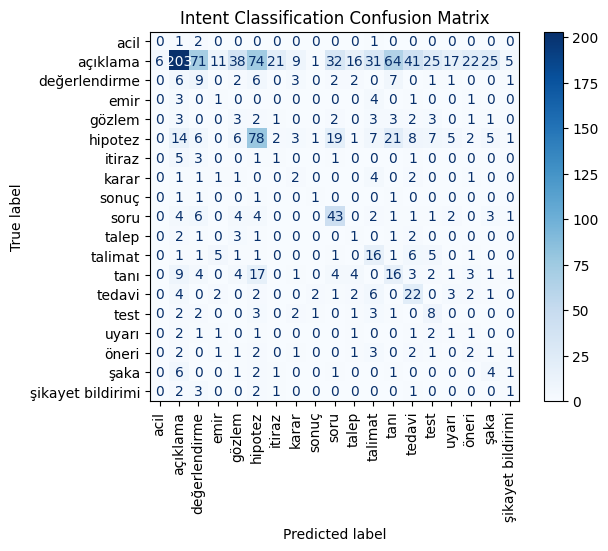

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Intent Classification Confusion Matrix")
plt.show()

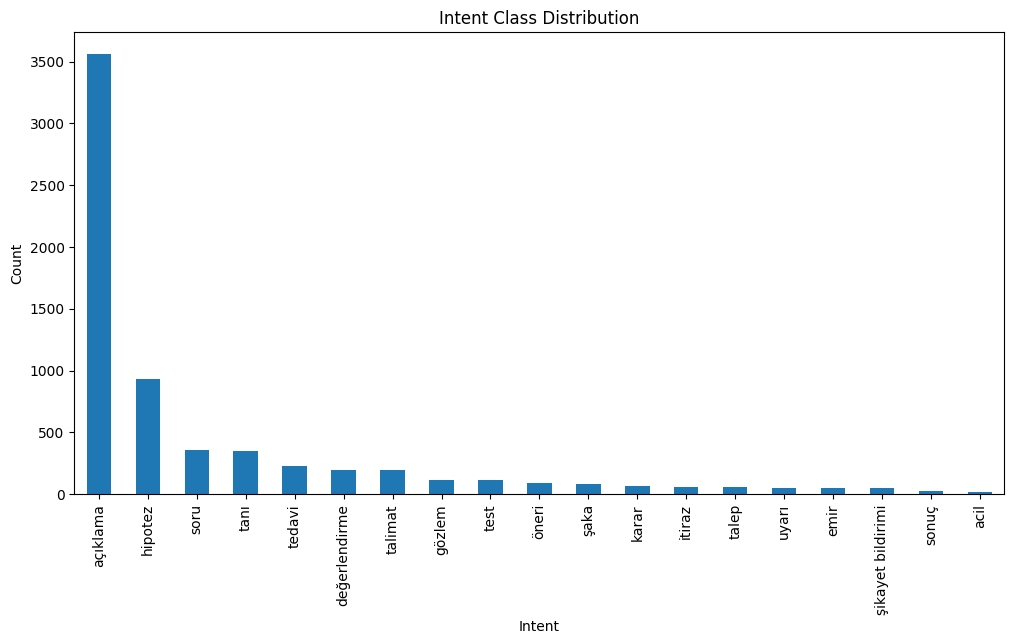

In [16]:
import matplotlib.pyplot as plt

df_intent["Intent"].value_counts().plot(kind="bar", figsize=(12, 6))

plt.title("Intent Class Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [17]:
import joblib

joblib.dump(model, "intent_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [18]:
results = pd.DataFrame({
    "Text": X_test,
    "Real_Intent": y_test,
    "Predicted_Intent": y_pred
})

results.to_excel("intent_predictions.xlsx", index=False)

print(results.head())

                                                   Text Real_Intent  \
5875                         dokularında lipit birikimi    açıklama   
6572  öte yandan antifosfolipid sendromu bunu açıkla...     hipotez   
1969  hipotalamustaki skar dokusu hipofize baskı yap...     hipotez   
7170                 i ki böbreğini de verirsen ölürsün       uyarı   
5368                hastada paroksismal taşikardi vardı    açıklama   

     Predicted_Intent  
5875         açıklama  
6572             tanı  
1969           tedavi  
7170         açıklama  
5368             tanı  
